# Notebook 2 — Décompression MPEG-G et Extraction des Mesures Brutes

## Objectifs

1. Décompresser TrainFiles.zip et TestFiles.zip
2. Convertir tous les fichiers .mgb -> .fastq via Docker Genie
3. Extraire les **mesures brutes** de chaque fichier FASTQ
4. Merger avec Train.csv et sauvegarder

## Mesures extraites dans ce notebook

| Mesure | Description |
|--------|-------------|
| `num_reads` | Nombre de séquences dans le fichier |
| `avg_read_length` | Longueur moyenne des reads (pb) |
| `avg_quality` | Qualité Phred moyenne |
| `pct_A`, `pct_T`, `pct_C`, `pct_G` | Fractions nucléotidiques |
| `pct_GC` | Fraction GC = pct_G + pct_C |


**⏱️ Temps estimé** : 6–10 heures (décompression à lancer la nuit)

---

In [ ]:
# import os
import zipfile
import subprocess
# import pandas as pd
# import numpy as np
from pathlib import Path
# from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print('✅ Imports standards OK')

✅ Imports standards OK


In [2]:
import sys
sys.path.append('../src')

from data_processing import (
    load_data,
    get_mgb_files,
    decode_all_mgb_files,
    extract_all_fastq_features,
    merge_with_metadata,
    save_processed_data,
)

print('✅ Fonctions importées depuis src/data_processing.py')

✅ Fonctions importées depuis src/data_processing.py


## 1. Configuration des chemins

In [3]:
DATA_PATH      = Path('../data/raw')
TRAIN_ZIP      = DATA_PATH / 'TrainFiles.zip'
TEST_ZIP       = DATA_PATH / 'TestFiles.zip'
TRAIN_MGB_PATH = DATA_PATH / 'TrainFiles'
TEST_MGB_PATH  = DATA_PATH / 'TestFiles'
PROCESSED_PATH = Path('../data/processed')
FIGURES_PATH   = Path('../results/figures')

PROCESSED_PATH.mkdir(exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f'📁 Raw       : {DATA_PATH.absolute()}')
print(f'📁 Processed : {PROCESSED_PATH.absolute()}')
print(f'📁 Figures   : {FIGURES_PATH.absolute()}')

📁 Raw       : /home/barry-4mad/Desktop/mpeg/fl-microbiome-mpegG/notebook/../data/raw
📁 Processed : /home/barry-4mad/Desktop/mpeg/fl-microbiome-mpegG/notebook/../data/processed
📁 Figures   : /home/barry-4mad/Desktop/mpeg/fl-microbiome-mpegG/notebook/../results/figures


## 2. Décompression des archives ZIP

In [4]:
def unzip_file(zip_path, extract_to):
    if not zip_path.exists():
        print(f'❌ Fichier ZIP non trouvé : {zip_path}')
        return False
    if extract_to.exists() and len(list(extract_to.glob('*.mgb'))) > 0:
        print(f'✅ Déjà décompressé : {extract_to.name} ({len(list(extract_to.glob("*.mgb")))} .mgb)')
        return True
    print(f'📦 Décompression de {zip_path.name}...')
    try:
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(extract_to.parent)
        print(f'✅ {len(list(extract_to.glob("*.mgb")))} fichiers .mgb extraits')
        return True
    except Exception as e:
        print(f'❌ Erreur : {e}')
        return False

print('=' * 50)
print('DÉCOMPRESSION TRAINFILES.ZIP')
print('=' * 50)
unzip_file(TRAIN_ZIP, TRAIN_MGB_PATH)

print()
print('=' * 50)
print('DÉCOMPRESSION TESTFILES.ZIP')
print('=' * 50)
unzip_file(TEST_ZIP, TEST_MGB_PATH)

DÉCOMPRESSION TRAINFILES.ZIP
✅ Déjà décompressé : TrainFiles (2901 .mgb)

DÉCOMPRESSION TESTFILES.ZIP
✅ Déjà décompressé : TestFiles (1068 .mgb)


True

## 3. Inventaire des fichiers .mgb

In [5]:
train_mgb_files = get_mgb_files(TRAIN_MGB_PATH)
test_mgb_files  = get_mgb_files(TEST_MGB_PATH)

print(f'\n📊 Total Train : {len(train_mgb_files)} fichiers')
print(f'📊 Total Test  : {len(test_mgb_files)} fichiers')
print(f'\n⏱️  Temps estimé décompression :')
print(f'   Train : ~{len(train_mgb_files) * 20 / 3600:.1f} heures')
print(f'   Test  : ~{len(test_mgb_files) * 20 / 3600:.1f} heures')

📁 ../data/raw/TrainFiles — 2901 fichiers .mgb
📁 ../data/raw/TestFiles — 1068 fichiers .mgb

📊 Total Train : 2901 fichiers
📊 Total Test  : 1068 fichiers

⏱️  Temps estimé décompression :
   Train : ~16.1 heures
   Test  : ~5.9 heures


## 4. Décompression MPEG-G -> FASTQ

⚠️ Lancer de préférence la nuit. Vérifier que Docker est actif et que l'espace disque est suffisant (~50–100 GB).

In [6]:
try:
    result = subprocess.run(['docker', '--version'], capture_output=True, text=True)
    print(f'✅ Docker : {result.stdout.strip()}')
except:
    print('❌ Docker non détecté — installer avant de continuer')

✅ Docker : Docker version 27.5.1, build 27.5.1-0ubuntu3~24.04.2


In [7]:
print('=' * 50)
print('DÉCOMPRESSION .MGB -> .FASTQ (TRAIN)')
print('=' * 50)
print(f'⏰ Début : {datetime.now().strftime("%H:%M:%S")}')

train_success = decode_all_mgb_files(
    train_mgb_files, skip_existing=True, desc='🧬 Train FASTQ'
)

print(f'⏰ Fin   : {datetime.now().strftime("%H:%M:%S")}')
print(f'✅ {train_success}/{len(train_mgb_files)} fichiers convertis')

DÉCOMPRESSION .MGB -> .FASTQ (TRAIN)
⏰ Début : 12:18:49


🧬 Train FASTQ: 100%|██████████| 2901/2901 [00:00<00:00, 52507.31it/s]


✅ 2901/2901 fichiers décompressés avec succès
⏰ Fin   : 12:18:49
✅ 2901/2901 fichiers convertis


In [8]:
print('=' * 50)
print('DÉCOMPRESSION .MGB -> .FASTQ (TEST)')
print('=' * 50)
print(f'⏰ Début : {datetime.now().strftime("%H:%M:%S")}')

test_success = decode_all_mgb_files(
    test_mgb_files, skip_existing=True, desc='🧬 Test FASTQ'
)

print(f'⏰ Fin   : {datetime.now().strftime("%H:%M:%S")}')
print(f'✅ {test_success}/{len(test_mgb_files)} fichiers convertis')

DÉCOMPRESSION .MGB -> .FASTQ (TEST)
⏰ Début : 12:18:56


🧬 Test FASTQ: 100%|██████████| 1068/1068 [00:00<00:00, 44518.71it/s]


✅ 1068/1068 fichiers décompressés avec succès
⏰ Fin   : 12:18:56
✅ 1068/1068 fichiers convertis


## 5. Extraction des mesures brutes

In [ ]:
print('=' * 50)
print('EXTRACTION MESURES BRUTES (TRAIN)')
print('=' * 50)
print(f'⏰ Début : {datetime.now().strftime("%H:%M:%S")}')

train_fastq_features = extract_all_fastq_features(train_mgb_files, desc='📊 Features Train')

print(f'⏰ Fin   : {datetime.now().strftime("%H:%M:%S")}')
print(f'\nAperçu :')
display(train_fastq_features.head())
print(f'\nStatistiques :')
display(train_fastq_features.describe())

EXTRACTION MESURES BRUTES (TRAIN)
⏰ Début : 12:36:10


📊 Features Train: 100%|██████████| 2901/2901 [1:42:58<00:00,  2.13s/it]    

✅ Features extraites : (2901, 9)
⏰ Fin   : 14:19:08

Aperçu :


,filename,num_reads,avg_read_length,avg_quality,pct_A,pct_T,pct_C,pct_G,pct_GC
0,ID_UZKLQI.mgb,10404,400.0,36.711846,0.225926,0.205424,0.216879,0.351771,0.568651
1,ID_HGLZKW.mgb,136008,124.5,33.936904,0.173470,0.265215,0.286912,0.274402,0.561314
2,ID_AJCSAH.mgb,16695,400.0,36.452803,0.266875,0.198437,0.224637,0.310051,0.534688
3,ID_OMWIDI.mgb,13824,400.0,36.563412,0.238720,0.201328,0.219903,0.340050,0.559952
4,ID_NQSIWB.mgb,27277,400.0,36.540316,0.227136,0.202357,0.219342,0.351165,0.570507



Statistiques :


,num_reads,avg_read_length,avg_quality,pct_A,pct_T,pct_C,pct_G,pct_GC
count,2.901000e+03,2901.000000,2901.000000,2901.000000,2901.000000,2901.000000,2901.000000,2901.000000
mean,1.616689e+05,268.945191,35.152869,0.226580,0.231125,0.247636,0.294658,0.542295
std,9.257161e+05,137.610917,1.548956,0.032908,0.035963,0.027307,0.035798,0.017636
min,1.300000e+01,124.500000,31.581530,0.168962,0.159720,0.207088,0.231287,0.490087
25%,1.668800e+04,124.500000,33.740567,0.202540,0.198845,0.221626,0.256895,0.527892
50%,3.096300e+04,400.000000,36.079416,0.222411,0.205737,0.228912,0.306189,0.541151
75%,1.182480e+05,400.000000,36.493488,0.264724,0.266768,0.273432,0.321551,0.557189
max,3.501304e+07,400.000000,37.229277,0.280293,0.284090,0.297871,0.363766,0.599869


In [ ]:
print('=' * 50)
print('EXTRACTION MESURES BRUTES (TEST)')
print('=' * 50)
print(f'⏰ Début : {datetime.now().strftime("%H:%M:%S")}')

test_fastq_features = extract_all_fastq_features(test_mgb_files, desc='📊 Features Test')

print(f'⏰ Fin   : {datetime.now().strftime("%H:%M:%S")}')
display(test_fastq_features.head())

EXTRACTION MESURES BRUTES (TEST)
⏰ Début : 14:19:08


📊 Features Test: 100%|██████████| 1068/1068 [20:41<00:00,  1.16s/it] 

✅ Features extraites : (1068, 9)
⏰ Fin   : 14:39:50


,filename,num_reads,avg_read_length,avg_quality,pct_A,pct_T,pct_C,pct_G,pct_GC
0,ID_IXPYEV.mgb,40313,400.0,36.661110,0.219899,0.204140,0.218394,0.357567,0.575961
1,ID_OCJFSP.mgb,401140,124.5,33.838746,0.206577,0.268548,0.270550,0.254325,0.524875
2,ID_HYTXHX.mgb,43900,400.0,36.583156,0.269500,0.186307,0.226752,0.317442,0.544193
3,ID_ZZIPPX.mgb,230108,124.5,32.514985,0.207865,0.271190,0.266901,0.254044,0.520945
4,ID_YXBJNZ.mgb,18100,124.5,34.082690,0.177967,0.265659,0.284991,0.271383,0.556374


## 6. Merge avec Train.csv

In [ ]:
train_df = load_data(DATA_PATH, 'Train.csv')

train_with_fastq = merge_with_metadata(train_fastq_features, train_df)

# print(f'\nColonnes : {train_with_fastq.columns.tolist()}')
display(train_with_fastq.head())

✅ Train.csv chargé : (2901, 4)
✅ Merge Train × FASTQ : (2901, 12)

Colonnes : ['filename', 'SampleType', 'SubjectID', 'SampleID', 'num_reads', 'avg_read_length', 'avg_quality', 'pct_A', 'pct_T', 'pct_C', 'pct_G', 'pct_GC']


,filename,SampleType,SubjectID,SampleID,num_reads,avg_read_length,avg_quality,pct_A,pct_T,pct_C,pct_G,pct_GC
0,ID_LETPJN.mgb,Stool,Subject_BCUNIB,Sample_AFTIWE,21599,400.0,36.898560,0.279865,0.191989,0.222465,0.305681,0.528146
1,ID_NTDGIW.mgb,Stool,Subject_UDAXIH,Sample_JQJVNK,20295,400.0,36.920443,0.268719,0.195539,0.221133,0.314609,0.535742
2,ID_ZISBMF.mgb,Nasal,Subject_VRKADI,Sample_YJWGWW,16449,400.0,36.368796,0.249779,0.198518,0.221118,0.330586,0.551703
3,ID_MDCVXU.mgb,Nasal,Subject_HIFZWD,Sample_VKEHZP,36965,400.0,36.151231,0.253585,0.201211,0.221141,0.324064,0.545204
4,ID_SWAMNY.mgb,Stool,Subject_VGLNCV,Sample_NTDTEQ,40236,400.0,36.416148,0.267547,0.195356,0.224603,0.312494,0.537097


## 7. Visualisations

Note : seules les **mesures brutes** sont visualisées ici.  

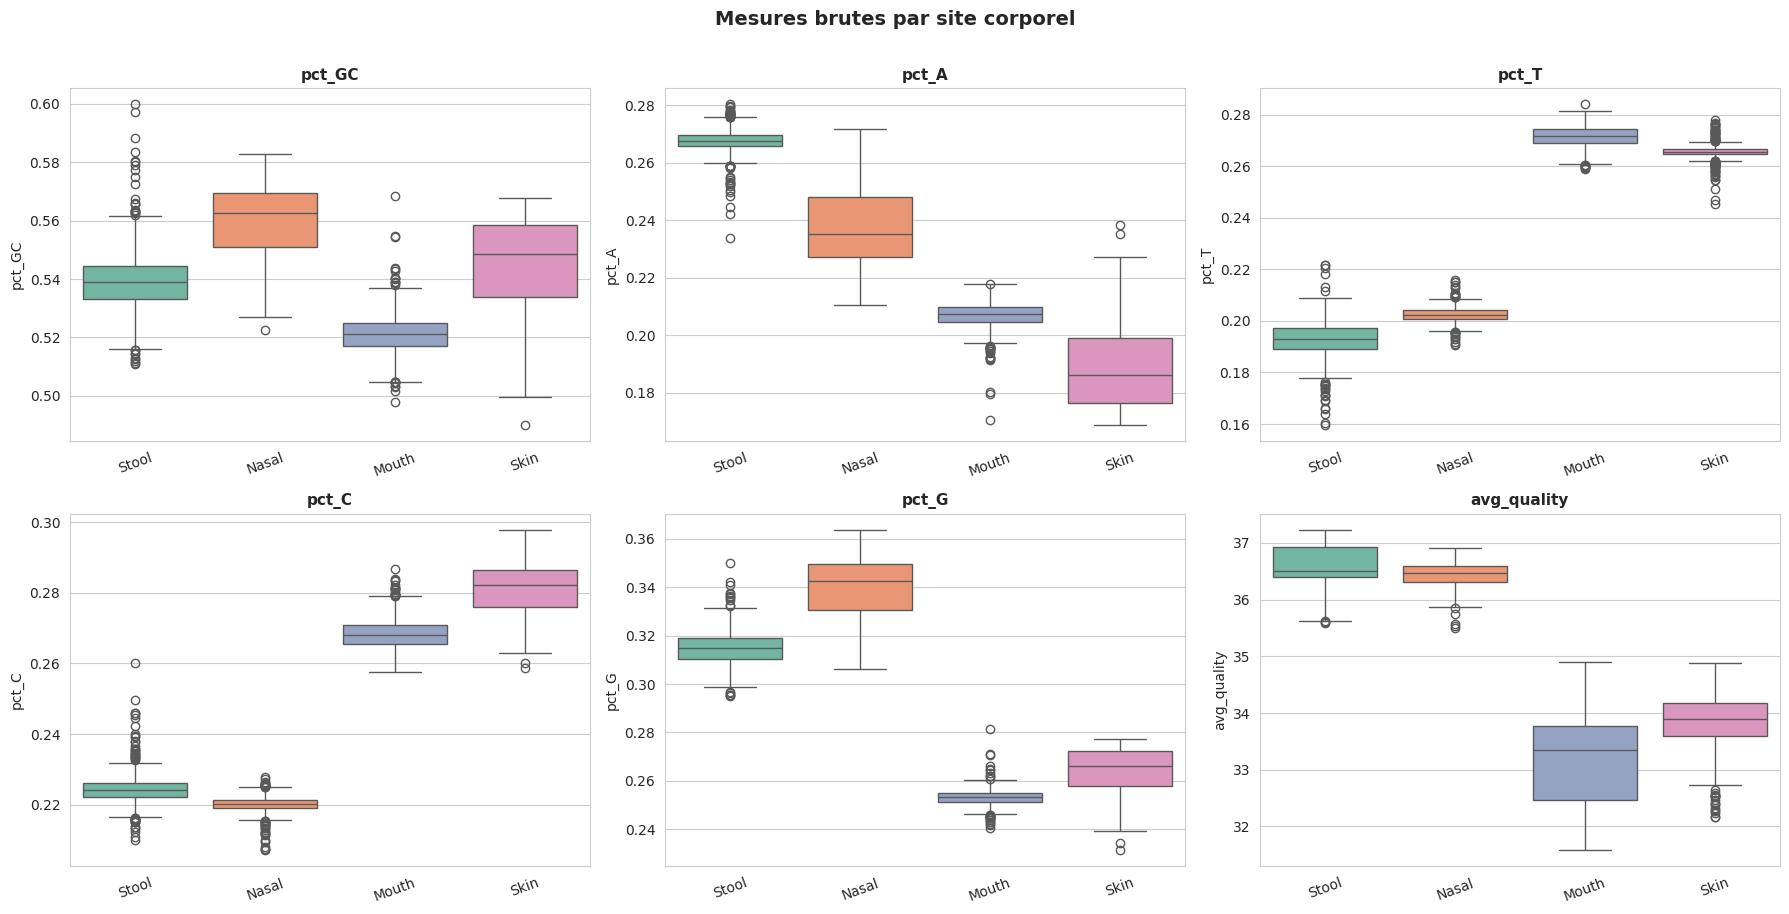

✅ Figure sauvegardée : 02_raw_features_by_sampletype.png


In [21]:
# Distribution des mesures brutes par site corporel
raw_features = ['pct_GC', 'pct_A', 'pct_T', 'pct_C', 'pct_G', 'avg_quality']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(raw_features):
    sns.boxplot(
        data=train_with_fastq,
        x='SampleType', y=feat,
        ax=axes[i], palette='Set2'
    )
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Mesures brutes par site corporel', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_raw_features_by_sampletype.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure sauvegardée : 02_raw_features_by_sampletype.png')

In [13]:
# Moyennes par SampleType
print('=' * 55)
print('MOYENNES DES MESURES BRUTES PAR SITE CORPOREL')
print('=' * 55)
grouped = train_with_fastq.groupby('SampleType')[raw_features].mean().round(4)
display(grouped)

MOYENNES DES MESURES BRUTES PAR SITE CORPOREL


,pct_GC,pct_A,pct_T,pct_C,pct_G,avg_quality,num_reads
SampleType,,,,,,,
Mouth,0.5213,0.2070,0.2717,0.2683,0.2531,33.2928,286820.8533
Nasal,0.5595,0.2381,0.2023,0.2201,0.3394,36.4380,24834.8831
Skin,0.5456,0.1886,0.2658,0.2809,0.2648,33.8815,331915.6493
Stool,0.5393,0.2677,0.1930,0.2244,0.3149,36.6216,24742.8311


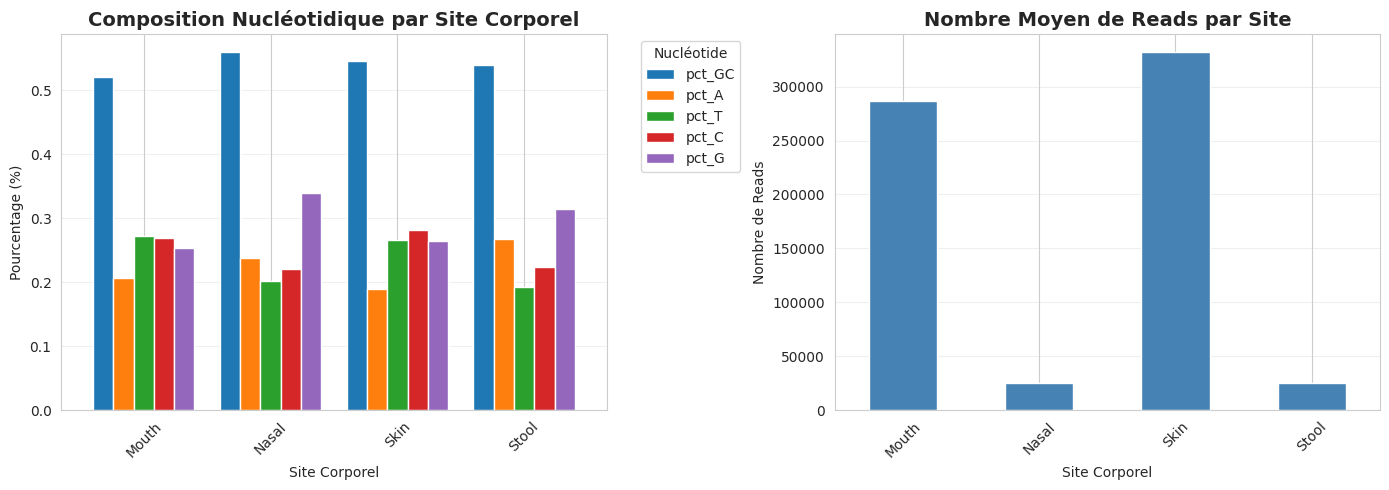

✅ Figure sauvegardée : 02_composition_by_sampletype.png


In [15]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grouped[['pct_GC', 'pct_A', 'pct_T', 'pct_C', 'pct_G']].plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Composition Nucléotidique par Site Corporel', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Pourcentage (%)')
axes[0].set_xlabel('Site Corporel')
axes[0].legend(title='Nucléotide', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

grouped['num_reads'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Nombre Moyen de Reads par Site', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Nombre de Reads')
axes[1].set_xlabel('Site Corporel')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_composition_by_sampletype.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure sauvegardée : 02_composition_by_sampletype.png")

## 8. Sauvegarde

In [14]:
print('=' * 55)
print('SAUVEGARDE')
print('=' * 55)

save_processed_data(train_with_fastq,    'train_fastq_features.csv', PROCESSED_PATH)
save_processed_data(test_fastq_features, 'test_fastq_features.csv',  PROCESSED_PATH)

print(f'\n✅ Fichiers sauvegardés dans {PROCESSED_PATH}')
print(f'⏰ {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

SAUVEGARDE
✅ Sauvegardé : ../data/processed/train_fastq_features.csv (2901, 12)
✅ Sauvegardé : ../data/processed/test_fastq_features.csv (1068, 9)

✅ Fichiers sauvegardés dans ../data/processed
⏰ 2026-05-02 14:47:53


## Résumé du Notebook 2

| Étape | Résultat |
|-------|----------|
| Fichiers .mgb Train | 2 901 convertis en .fastq |
| Fichiers .mgb Test | 1 068 convertis en .fastq |
| Mesures extraites | num_reads, avg_read_length, avg_quality, pct_A/T/C/G, pct_GC |
| Output Train | `data/processed/train_fastq_features.csv` — (2901, 12) |
| Output Test | `data/processed/test_fastq_features.csv` — (1068, 9) |
